# ACF - PACF direct exemple

In [5]:
#import des librairies python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime

In [18]:
#Genère une serie temporelle aléatoire 
date_range = pd.date_range(start='1/1/2021', end='31/12/2021', freq='D')
df = pd.DataFrame(date_range, columns=['date'])
df['data'] = np.random.randint(0,100,size=(len(date_range)))
df['date_time'] = pd.to_datetime(df['date'])
df = df.set_index('date_time')
df.drop(['date'], axis=1, inplace=True)

## Nous allons içi exposer l'exemple de l'ACF et du PACF. Ce code est en lien avec l'article suivant:

[Série temporelle, autocorrélation et autorégression](https://www.heroldjb.com/analyse-des-series-temporelles-2-2/)


Text(0, 0.5, 'Value')

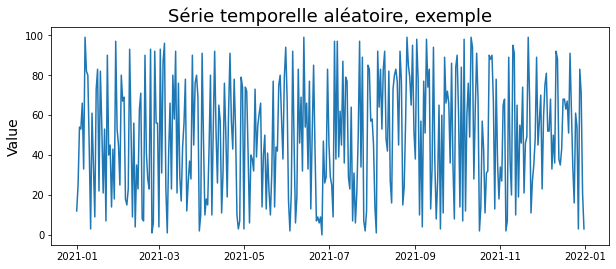

In [30]:
#genere le graphique de notre série
plt.figure(figsize=(10,4))
plt.plot(df.data)
plt.title('Série temporelle aléatoire, exemple', fontsize=18)
plt.ylabel('Value',fontsize=14)

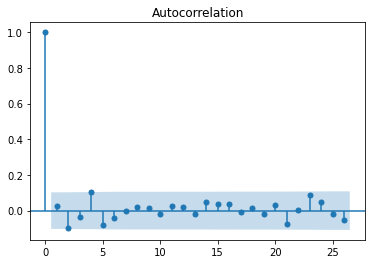

In [38]:
#Genere le graphe de la fonction d'autocorrélation ACF
acf = plot_acf(df.data)

## Interprétation de la fonction d'autocorrélation

Nous avons sélectionner un lag qui est notre intervalle de temps, le lag içi n'est pas spécifié aussi l'outil en choisi un pour nous.
Nous voyons apparaitre une bande bleu qui est la zone de non signification.

Si les valeur que peuvent prendre à chaque instant t (lag 1, lag 2, donc de xjours en x jours, x ayant été choisi par l'outil pour rappel) sortent de cette bande de signification alors nous pouvons considérer qu'il y a corrélation à l'instant t constaté.

Dans notre exemple içi, nous remarquons:
* aucune des valeur ne sort de la bande de signification.<br>

* les valeurs ne sont pas décroissantes avec le temps par conséquent le modèle ne perd pas de sa pertinence avec le temps<br>
Or il devrait puisque la corrélation est de moins en moins pertinente plus le temps passe puisque nous avons vu que ACF intégrait les 

Nous ne sommes donc pas en face d'une série autocoréllée.

**Cela est logique puisque nous avons generé des nombres aléatoires, ils n'ont aucun lien de corrélation entre eux!!**

Regardons le PACF

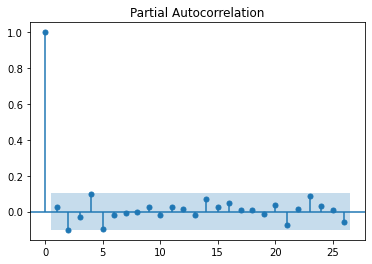

In [39]:
pacf = plot_pacf(df)

Là encore aucune valeur ne sort de la bande de signification. Même constat.

## Exemple avec une série temporelle réelle

In [74]:
#import du fichier .xlsx téléchargé at: https://data.world/datasets/time-series
#Extrait d'un dataset sur les prix du fuel aux US
#Mise en place de notre série temporelle
df_real = pd.read_excel('fuelPrices.xlsx')
df_petrol_price = df_real[['Date', 'Petrol (USD)']]
df_petrol_price = df_petrol_price.iloc[0:881]
df_petrol_price['date_time'] = pd.to_datetime(df_petrol_price['Date'])
df_petrol_price = df_petrol_price.set_index('date_time')
df_petrol_price.drop(['Date'], axis=1, inplace=True)
df_petrol_price.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 881 entries, 2003-06-09 to 2020-04-20
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Petrol (USD)  881 non-null    float64
dtypes: float64(1)
memory usage: 13.8 KB


Text(0, 0.5, 'Value')

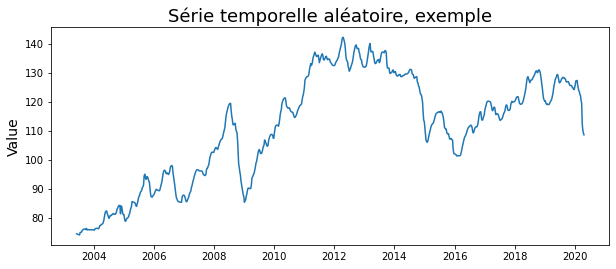

In [77]:
#genere le graphique de notre série
plt.figure(figsize=(10,4))
plt.plot(df_petrol_price['Petrol (USD)'])
plt.title('Série temporelle aléatoire, exemple', fontsize=18)
plt.ylabel('Value',fontsize=14)

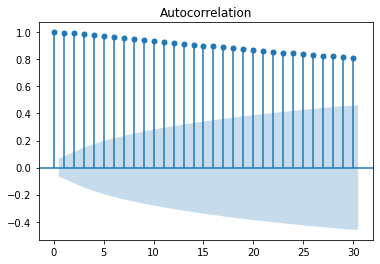

In [83]:
#Genere le graphe de la fonction d'autocorrélation ACF
acf = plot_acf(df_petrol_price['Petrol (USD)'])

Içi nous constatons que la série est fortement corrélée puisque l'ensemble des valeurs dépassent la zone de signification avec un lag de 30.

Par ailleurs il semble y avoir une tendance décroissance, nous pouvons regarder en augmentant le lag.

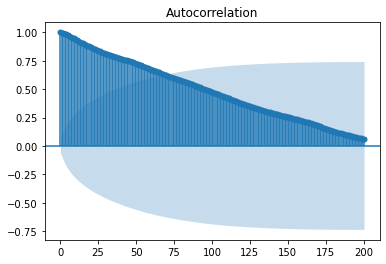

In [86]:
#Genere le graphe de la fonction d'autocorrélation ACF lag augmenté
acf = plot_acf(df_petrol_price['Petrol (USD)'], lags=200)

Nous constatons donc une décroissance, nous sommes face à un modèle autorégressif.

Traçons le PACF:

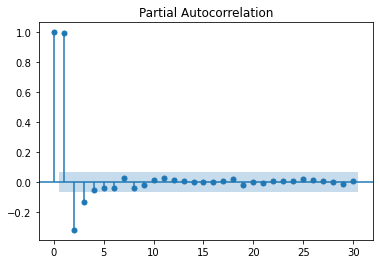

In [92]:
pacf = plot_pacf(df_petrol_price)

Nous voyons içi que nous avons les ordre de 1 à 3 qui sortent grandement de la zone de signification.

Nous choisirions un lag 3 pour établir un modèle mathématique basé sur la fonction partielle d'autocorrélation.

Revenons à l'article : [Série temporelle, autocorrélation et autorégression](https://www.heroldjb.com/analyse-des-series-temporelles-2-2/)